# 개발자 번아웃 예측 모델 개선 실험
**목표: 파생 변수 생성 및 SMOTE 적용을 통한 정확도 극대화 시도**


---

## 1. 데이터 로드 및 기본 전처리
기존 데이터셋을 불러오고 결측치를 최빈값과 평균값으로 처리합니다.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset
from imblearn.over_sampling import SMOTE

data = pd.read_csv('/content/sample_data/developer_burnout_dataset_7000.csv')

data['burnout_level'] = data['burnout_level'].fillna(data['burnout_level'].mode()[0])
data['burnout_level'] = data['burnout_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

data.fillna(data.mean(numeric_only=True), inplace=True)

## 2. 피처 엔지니어링 (파생 변수 추가)
단일 피처만으로는 설명하기 힘든 번아웃 상태를 포착하기 위해 비율 기반 파생 변수를 도입합니다.

In [7]:
# 1. 수면 대비 업무 비율 (휴식 부족 지표)
data['work_sleep_ratio'] = data['daily_work_hours'] / (data['sleep_hours'] + 1)
# 2. 업무 대비 운동 비율 (스트레스 해소 지표)
data['exercise_work_ratio'] = data['exercise_hours'] / (data['daily_work_hours'] + 1)
# 3. 화면 노출 대비 수면 비율 (피로도 지표)
data['screen_sleep_ratio'] = data['screen_time'] / (data['sleep_hours'] + 1)
# 4. 커밋 대비 버그 비율 (업무 효율성 지표)
data['bug_commit_ratio'] = data['bugs_per_day'] / (data['commits_per_day'] + 1)

feature_columns = [
    'age', 'experience_years', 'daily_work_hours', 'sleep_hours',
    'caffeine_intake', 'bugs_per_day', 'commits_per_day',
    'meetings_per_day', 'screen_time', 'exercise_hours',
    'work_sleep_ratio', 'exercise_work_ratio', 'screen_sleep_ratio', 'bug_commit_ratio'
]
X = data[feature_columns]
y = data['burnout_level']

## 3. 데이터 불균형 해소 (SMOTE) 및 스케일링
클래스 간 불균형을 해결하기 위해 SMOTE로 소수 데이터를 증강하고 정규화를 진행합니다.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE 적용
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

mm = MinMaxScaler()
X_train_scaled = mm.fit_transform(X_train_resampled)
X_test_scaled = mm.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train_resampled.values)
y_test_tensor = torch.LongTensor(y_test.values)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

## 4. 딥러닝 모델 설계 및 학습
4계층 신경망 구조를 사용하여 복잡한 패턴 학습을 유도합니다.

In [14]:
class BurnoutModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 3)
        )
    def forward(self, x): return self.layer(x)

model = BurnoutModel(len(feature_columns))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 200
patience = 15
best_test_loss = float("inf")
counter = 0
history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = correct / total

    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            test_loss += criterion(outputs, y_batch).item()
            predicted = torch.argmax(outputs, dim=1)
            test_correct += (predicted == y_batch).sum().item()
            test_total += y_batch.size(0)

    avg_test_loss = test_loss / len(test_loader)
    test_acc = test_correct / test_total

    history["train_loss"].append(avg_train_loss)
    history["test_loss"].append(avg_test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  > Train | Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f}")
        print(f"  > Test  | Loss: {avg_test_loss:.4f}, Acc: {test_acc:.4f}")
        print("-" * 40)

    # Early Stopping (Test Loss 기준)
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f"== Early Stopping triggered at Epoch {epoch+1} ==")
            break

Epoch [10/200]
  > Train | Loss: 0.4411, Acc: 0.8041
  > Test  | Loss: 0.5084, Acc: 0.7679
----------------------------------------
Epoch [20/200]
  > Train | Loss: 0.4274, Acc: 0.8113
  > Test  | Loss: 0.5019, Acc: 0.7714
----------------------------------------
Epoch [30/200]
  > Train | Loss: 0.4222, Acc: 0.8174
  > Test  | Loss: 0.5251, Acc: 0.7571
----------------------------------------
Epoch [40/200]
  > Train | Loss: 0.4123, Acc: 0.8200
  > Test  | Loss: 0.5331, Acc: 0.7614
----------------------------------------
== Early Stopping triggered at Epoch 42 ==


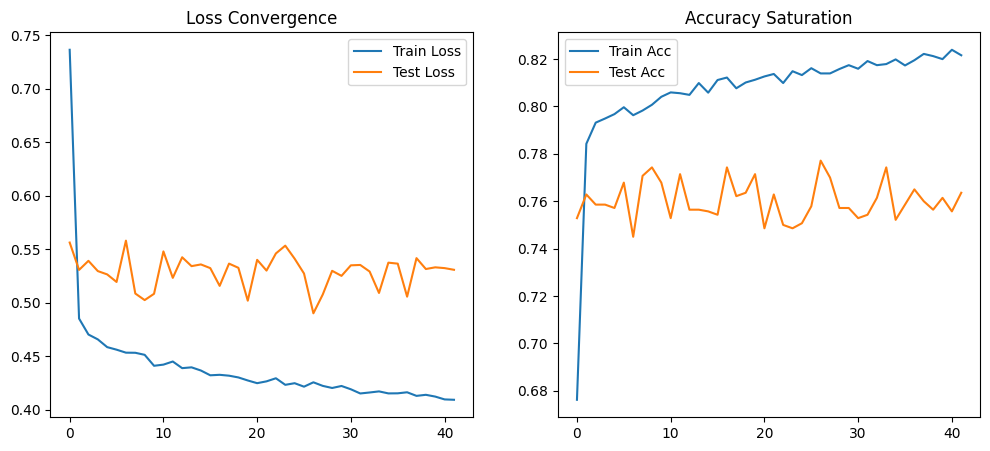

In [15]:
plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss Convergence')
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy Saturation')
plt.legend()

plt.show()

## 5. 최종 결과 분석: 성능 정체와 데이터의 한계
실험 결과, 정확도는 75~80% 사이에서 수렴하였습니다.

### Classification Report ###
              precision    recall  f1-score   support

         Low       0.74      0.81      0.77       324
      Medium       0.82      0.76      0.78       753
        High       0.74      0.80      0.77       323

    accuracy                           0.78      1400
   macro avg       0.76      0.79      0.77      1400
weighted avg       0.78      0.78      0.78      1400



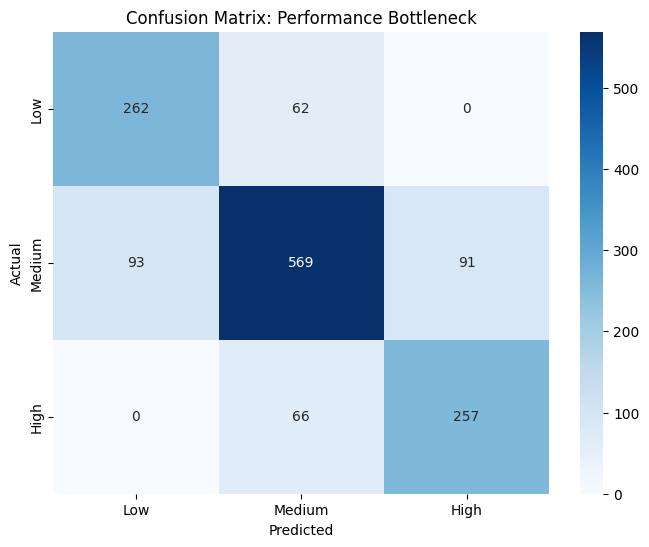

In [16]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
with torch.no_grad():
    y_pred = torch.argmax(model(X_test_tensor), dim=1)

print("### Classification Report ###")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix: Performance Bottleneck')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

###  결론 및 분석 포인트
1. **성능 정체**: 파생 변수 추가와 SMOTE 적용이라는 최적의 조합을 사용했음에도 불구하고 Test Accuracy는 75~80%에 수렴함.
2. **혼동 행렬 분석**: 모델이 여전히 `Medium` 클래스를 `Low`나 `High`와 명확하게 구분하지 못하는 현상이 두드러짐.
3. **데이터의 선형적 한계**: 이는 모델 구조의 문제가 아닌, **데이터셋 자체의 선형적 한계**로 판단됨.
   - 번아웃 지표들(수면, 업무시간 등)이 서로 다른 클래스 간에 밀접하게 겹쳐 있어(Overlap), 현재 제공된 피처만으로는 경계선을 완벽히 분리하는 것이 불가능함.